In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
df = pd.read_csv("data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
df[:1]

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.40575,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.82789,0.290202,0.026601,0.56405,1,0.016469


#EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
df.duplicated().sum()

np.int64(0)

## Absolute Frequency of Classes

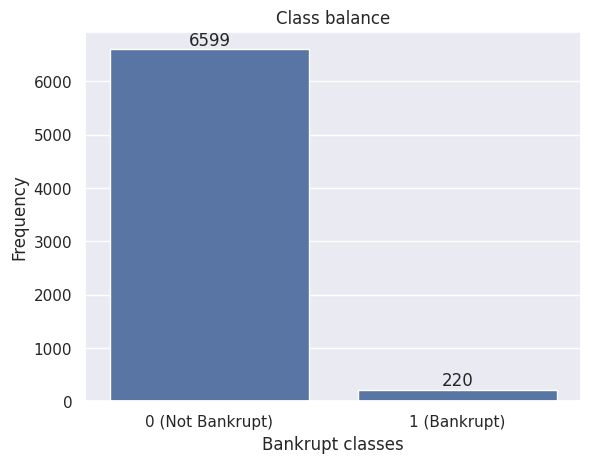

In [6]:
ax = sns.countplot(data=df, x='Bankrupt?')
ax.bar_label(ax.containers[0])

# Map ticks to custom labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (Not Bankrupt)', '1 (Bankrupt)'])

plt.xlabel("Bankrupt classes")
plt.ylabel("Frequency")
plt.title("Class balance");

## Distributions of "Net Income to Total Assets" column for both Classes

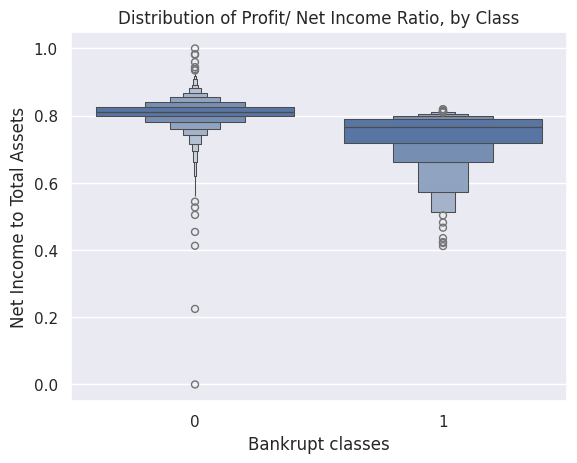

In [7]:
sns.boxenplot(x="Bankrupt?" , y=" Net Income to Total Assets" , data=df)
plt.xlabel("Bankrupt classes")
plt.ylabel("Net Income to Total Assets")
plt.title("Distribution of Profit/ Net Income Ratio, by Class");

## Plotting Boxplots of the numerical features

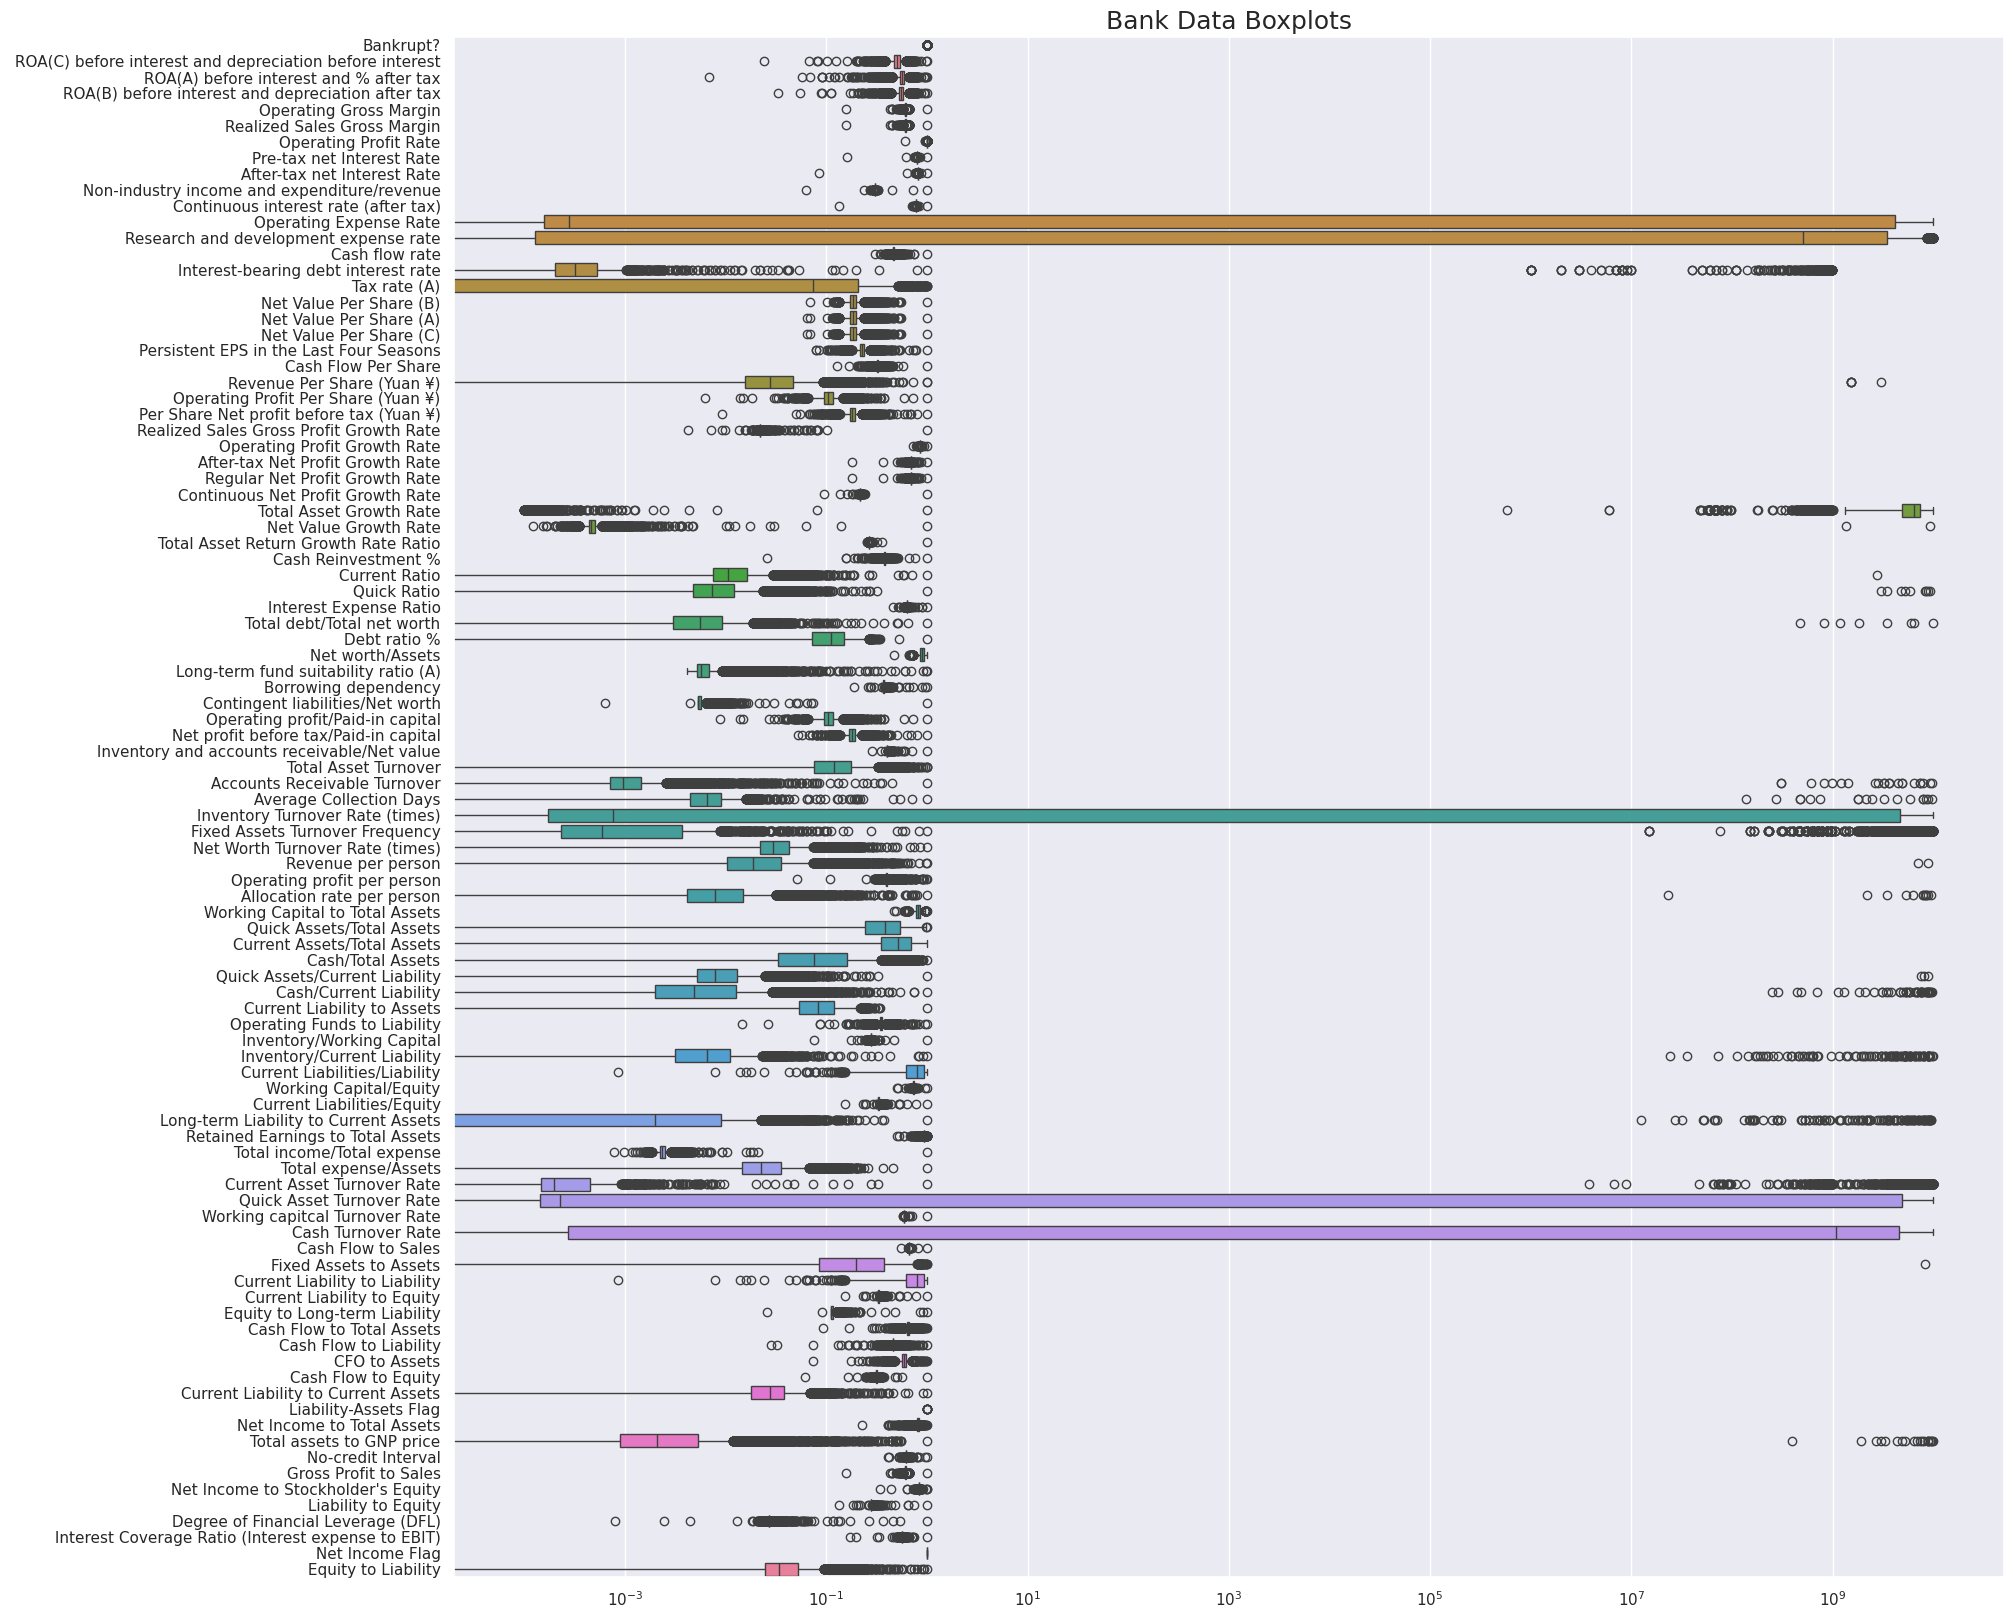

In [8]:
plt.figure(figsize = (20,20))
ax =sns.boxplot(data = df, orient="h")
ax.set_title('Bank Data Boxplots', fontsize = 18)
ax.set(xscale="log")
plt.show()

## Check for Multicollinearity with Correlation Heatmap (Spearman)

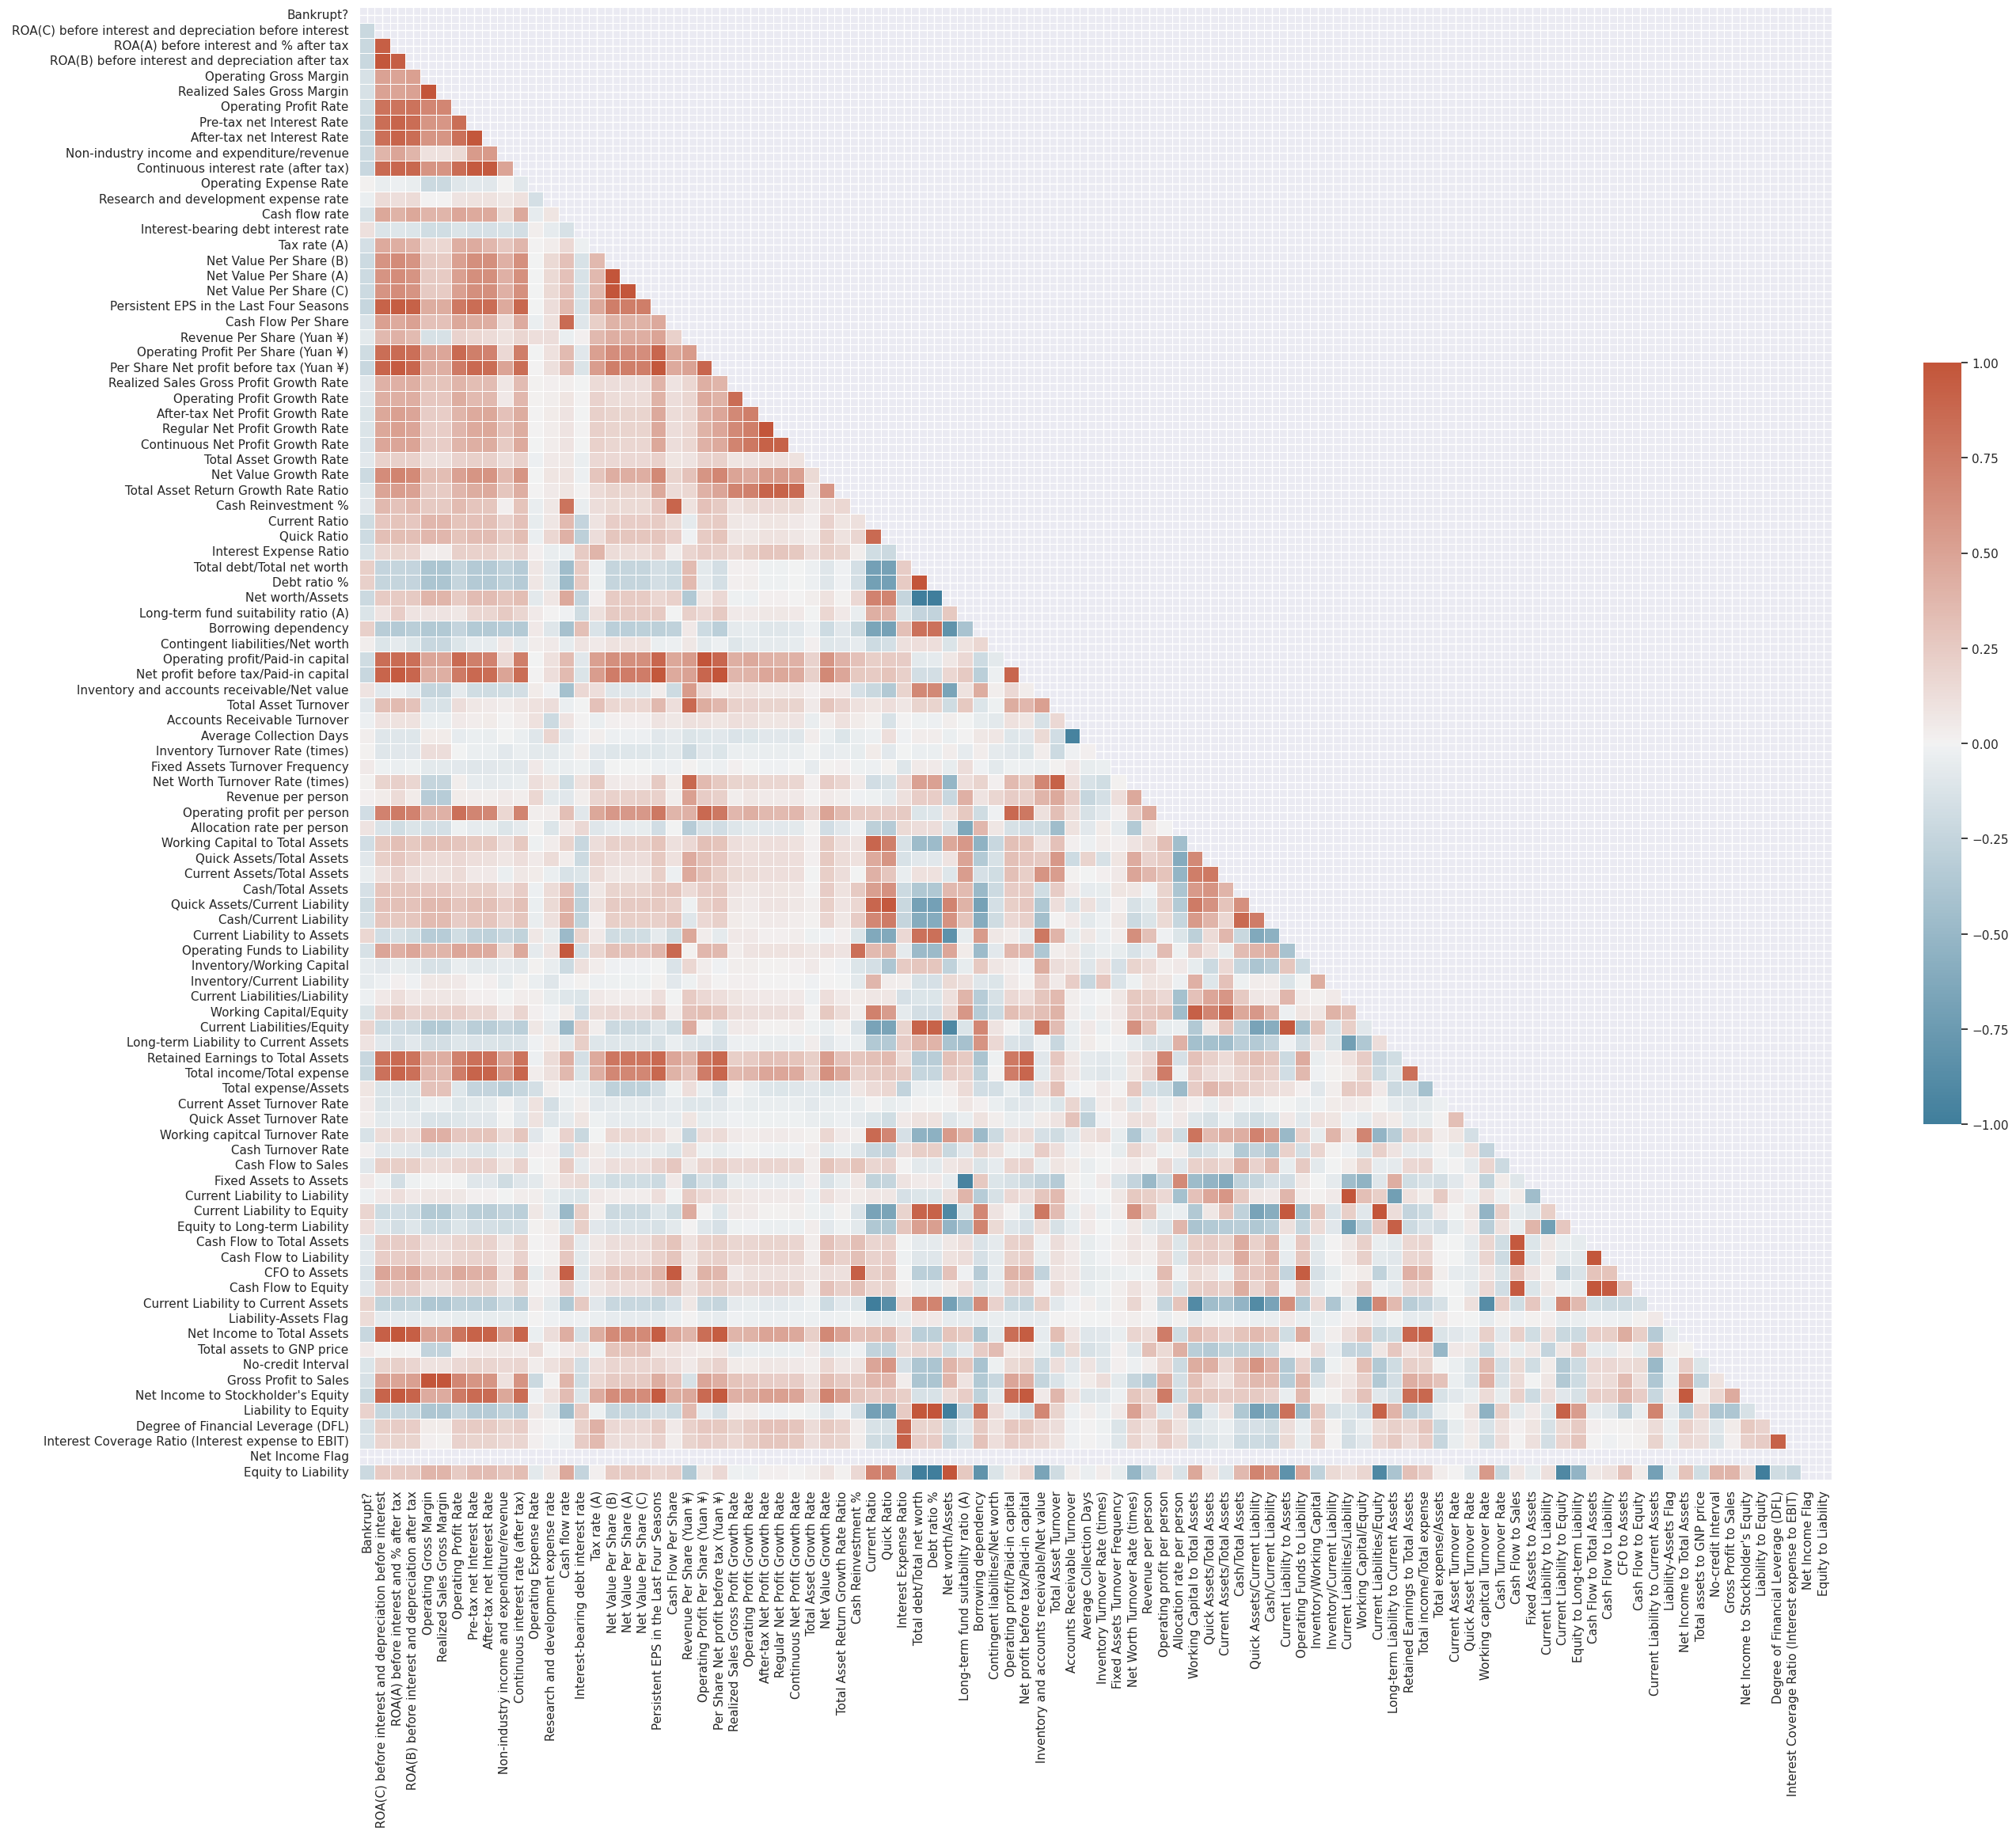

In [9]:
f, ax = plt.subplots(figsize=(30, 25))
mat = df.corr('spearman')
mask = np.triu(np.ones_like(mat, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(mat, mask=mask, cmap=cmap, vmax=1, center=0,# annot = True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

# Preprocessing

## Train Test Split

In [10]:
x = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

x.shape, y.shape

((6819, 95), (6819,))

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5455, 95)
y_train shape: (5455,)
X_test shape: (1364, 95)
y_test shape: (1364,)


## Get Accuracy of Baseline Model

In [13]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.969


# Hyperparameter Tuning with Random Forest
###Reasons to pick Random Forest
1. The dataset has 95 feature columns. Random Forest handles High Dimensionality well.
2. Random Forest is immmune to performance drops from Multicollinearity.
3. It is not affected by Outliers.
4. It does not need Feature Scaling.

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

In [63]:
params = {
    "n_estimators": [125, 175],
    "max_depth": [2, 3, 5],
    "min_samples_split": [225, 275, 325],
    "min_samples_leaf": [90, 110, 130]
    }

In [64]:
#Since minimizing False Negative(when Bankruptcy is predicted Not Bankruptcy) is more important in this case, we use 'recall'.
model = GridSearchCV(
    rfc,
    param_grid =params,
    cv=5,
    scoring='recall',  # Switches optimization focus from Accuracy to recall.
    n_jobs=-1,
    verbose=1)

In [65]:
model.fit(x_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5],
                         'min_samples_leaf': [90, 110, 130],
                         'min_samples_split': [225, 275, 325],
                         'n_estimators': [125, 175]},
             scoring='recall', verbose=1)

In [66]:
pd.DataFrame(model.cv_results_).sort_values('rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
29,4.445943,0.617001,0.036950,0.005666,3,110,325,175,"{'max_depth': 3, 'min_samples_leaf': 110, 'min...",0.969697,0.823529,0.794118,0.823529,0.852941,0.852763,0.061355,1
23,4.713336,0.883365,0.032661,0.000293,3,90,325,175,"{'max_depth': 3, 'min_samples_leaf': 90, 'min_...",0.969697,0.823529,0.794118,0.823529,0.852941,0.852763,0.061355,1
39,5.735920,0.873322,0.036037,0.003432,5,90,275,175,"{'max_depth': 5, 'min_samples_leaf': 90, 'min_...",0.969697,0.823529,0.794118,0.823529,0.852941,0.852763,0.061355,1
49,5.581415,0.830955,0.042631,0.015246,5,130,225,175,"{'max_depth': 5, 'min_samples_leaf': 130, 'min...",0.969697,0.823529,0.823529,0.794118,0.852941,0.852763,0.061355,1
43,5.685252,0.855432,0.045362,0.013751,5,110,225,175,"{'max_depth': 5, 'min_samples_leaf': 110, 'min...",0.969697,0.823529,0.794118,0.823529,0.852941,0.852763,0.061355,1


In [67]:
model.best_params_

{'max_depth': 3,
 'min_samples_leaf': 90,
 'min_samples_split': 325,
 'n_estimators': 175}

#Evaluate

--- Results with Threshold = 0.25 ---
Accuracy: 0.7214

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.71      0.83      1313
           1       0.11      0.94      0.20        51

    accuracy                           0.72      1364
   macro avg       0.55      0.83      0.52      1364
weighted avg       0.96      0.72      0.81      1364



In [69]:
train_recall = model.score(x_train , y_train)
test_recall = model.score(x_test , y_test)

#call .score() directly on best_estimator_, which defaults to accuracy
train_accuracy = model.best_estimator_.score(x_train, y_train)
test_accuracy = model.best_estimator_.score(x_test, y_test)

print(f"Training accuracy: {round(train_accuracy, 4)}")
print(f"Test accuracy: {round(test_accuracy, 4)}")
print(f"Training recall: {round(train_recall  , 4)}")
print(f"test recall: {round(test_recall  , 4)}")

Training accuracy: 0.8834
Test accuracy: 0.8673
Training recall: 0.9053
test recall: 0.8235


## Classification Report and Confusion Matrix with predicted and actual values

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay , classification_report ,f1_score

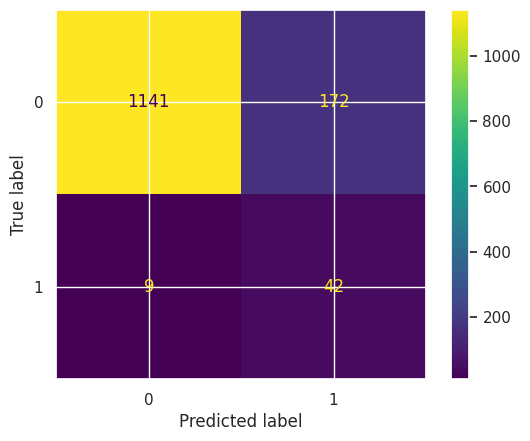

In [71]:
ConfusionMatrixDisplay.from_estimator(model,
                                      x_test,
                                      y_test);

In [72]:
print(classification_report(y_test,
    model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1313
           1       0.20      0.82      0.32        51

    accuracy                           0.87      1364
   macro avg       0.59      0.85      0.62      1364
weighted avg       0.96      0.87      0.90      1364



## Report with threshold

In [83]:
# Get predicted probabilities for class 1 (Bankrupt)
y_probs = model.predict_proba(x_test)[:, 1]

custom_threshold = 0.25
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"--- Results with Threshold = {custom_threshold} ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_custom), 4))
print(classification_report(y_test, y_pred_custom))

--- Results with Threshold = 0.25 ---
Accuracy: 0.7214
              precision    recall  f1-score   support

           0       1.00      0.71      0.83      1313
           1       0.11      0.94      0.20        51

    accuracy                           0.72      1364
   macro avg       0.55      0.83      0.52      1364
weighted avg       0.96      0.72      0.81      1364



# Feature Importances

In [73]:
feature_importances = model.best_estimator_.feature_importances_
feature_importances_series = pd.Series(feature_importances, index=x_test.columns).sort_values()


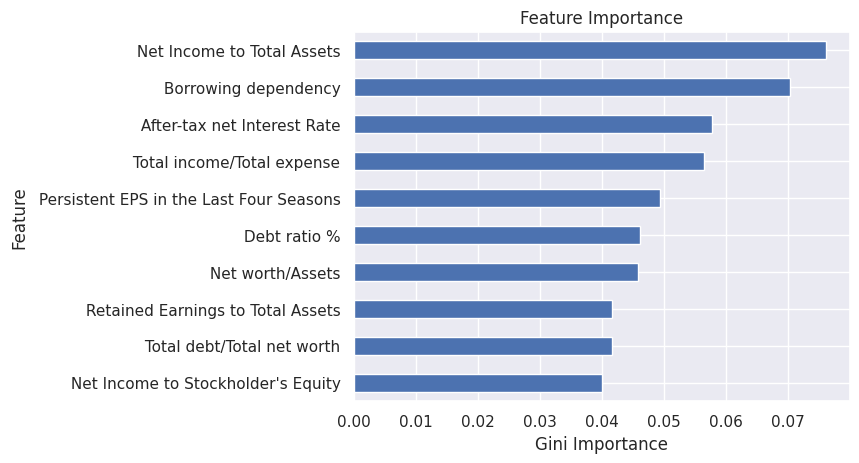

In [74]:
feature_importances_series.tail(10).plot(kind= 'barh')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance");

#Export Model and Feature Medians

In [75]:
best_rfc = RandomForestClassifier(
    max_depth = 3,
    min_samples_leaf = 90,
    min_samples_split = 325,
    n_estimators = 175,
    class_weight = 'balanced')

In [76]:
best_rfc.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=90, min_samples_split=325,
                       n_estimators=175)

In [77]:
import joblib

# Export the trained model
joblib.dump(best_rfc, 'rf_model.pkl')

['rf_model.pkl']

In [78]:
import json

# Median of each of the 95 features, computed on x_train (pre-oversampling,
# pre-test-split) so it reflects the real training distribution with no
# duplicated rows (from RandomOverSampler) and no leakage from x_test.
feature_medians = x_train.median()

assert list(feature_medians.index) == list(x_train.columns)

# Save as a dict (column_name -> median). A dict/Series preserves the exact
# column order the model expects -- the Streamlit app should build its
# input row using this same order.
medians_dict = feature_medians.to_dict()
joblib.dump(medians_dict, 'feature_medians.pkl')

# Also save a JSON copy -- easy to inspect/version, and loadable without pandas
with open('feature_medians.json', 'w') as f:
    json.dump(medians_dict, f, indent=2)

print(f"Exported medians for {len(medians_dict)} features to feature_medians.pkl / .json")
feature_medians.head()

Exported medians for 95 features to feature_medians.pkl / .json


,0
ROA(C) before interest and depreciation before interest,0.503144
ROA(A) before interest and % after tax,0.560347
ROA(B) before interest and depreciation after tax,0.552599
Operating Gross Margin,0.606041
Realized Sales Gross Margin,0.606005


In [84]:
import sklearn, xgboost, joblib #check versions to put in requirements.txt
print(sklearn.__version__, xgboost.__version__, joblib.__version__)

1.6.1 3.4.0 1.5.3
